### K-Means Clustering on Iris Dataset

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Cluster Labels:
Cluster
0    62
1    50
2    38
Name: count, dtype: int64

First 10 predictions:
       Species  Cluster
0  Iris-setosa        1
1  Iris-setosa        1
2  Iris-setosa        1
3  Iris-setosa        1
4  Iris-setosa        1
5  Iris-setosa        1
6  Iris-setosa        1
7  Iris-setosa        1
8  Iris-setosa        1
9  Iris-setosa        1


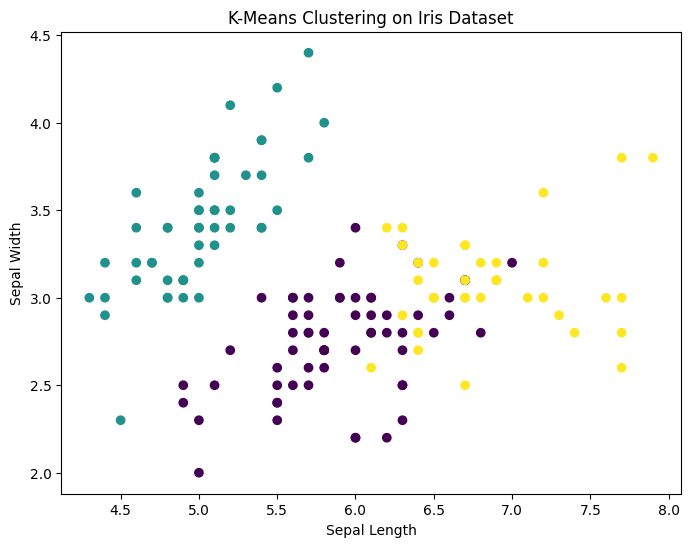

In [6]:


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

df = pd.read_csv(r"D:\Iris.csv")

print(df.head())

X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

print("\nCluster Labels:")
print(df["Cluster"].value_counts())

print("\nFirst 10 predictions:")
print(df[["Species", "Cluster"]].head(10))

plt.figure(figsize=(8, 6))

plt.scatter(
    df["SepalLengthCm"],
    df["SepalWidthCm"],
    c=df["Cluster"]
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering on Iris Dataset")

plt.show()

# PCA - Dimensionality Reduction

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

PCA Reduced Dataset:
   Principal Component 1  Principal Component 2
0              -2.264542               0.505704
1              -2.086426              -0.655405
2              -2.367950              -0.318477
3              -2.304197              -0.575368
4              -2.388777               0.674767

Explained Variance Ratio:
[0.72770452 0.23030523]

Total Explained Variance:
0.9580097536148195


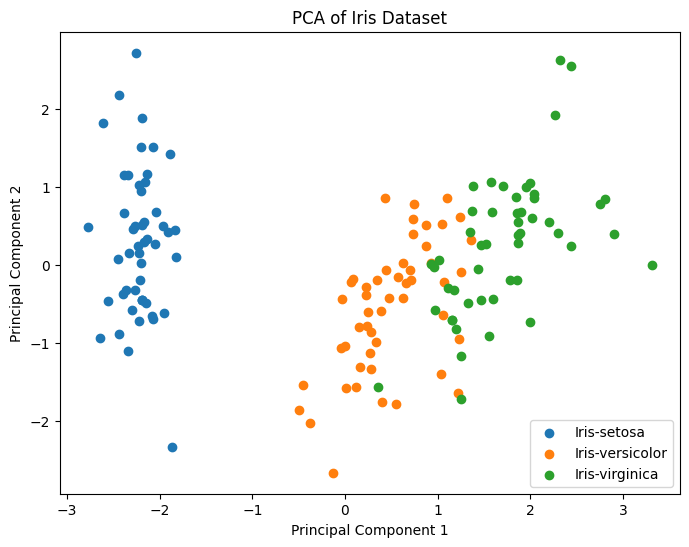

In [7]:


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(r"D:\Iris.csv")

print(df.head())

X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)

print("\nPCA Reduced Dataset:")
print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())

pca_df["Species"] = df["Species"]

plt.figure(figsize=(8, 6))

for species in pca_df["Species"].unique():

    data = pca_df[pca_df["Species"] == species]

    plt.scatter(
        data["Principal Component 1"],
        data["Principal Component 2"],
        label=species
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA of Iris Dataset")

plt.legend()

plt.show()